In [1]:
import pandas as pd
import re

In [4]:
import pandas as pd
import re
import numpy as np

def clean_frb_name(name):
    if pd.isna(name):
        return ""
    cleaned = str(name).strip().upper()
    cleaned = re.sub(r'^FRB\s*', '', cleaned)
    cleaned = re.sub(r'\s+', '', cleaned)
    return cleaned

def cross_match_catalogs(baseband_path, cat2_path, output_path='cross_matched_frb_catalog.csv'):
    df_baseband = pd.read_csv(baseband_path)
    df_cat2 = pd.read_csv(cat2_path)

    cat2_name_col = None
    possible_name_cols = ['TNS name', 'tns_name', 'FRB', 'frb_name', 'name', 'tns']
    for col in df_cat2.columns:
        if col.strip().lower() in [c.lower() for c in possible_name_cols]:
            cat2_name_col = col
            break

    if cat2_name_col is None:
        raise KeyError(f"Could not automatically find the FRB/TNS name column in Catalog 2. Available columns: {list(df_cat2.columns)}")

    df_baseband['match_key'] = df_baseband['TNS name'].apply(clean_frb_name)
    df_cat2['match_key'] = df_cat2[cat2_name_col].apply(clean_frb_name)

    df_baseband = df_baseband.drop_duplicates(subset='match_key', keep='first')
    df_cat2 = df_cat2.drop_duplicates(subset='match_key', keep='first')

    cat2_ra_col = 'ra' if 'ra' in df_cat2.columns else 'RA'
    cat2_ra_err_col = 'ra_err' if 'ra_err' in df_cat2.columns else ('sigma_RA' if 'sigma_RA' in df_cat2.columns else 'RA_err')
    cat2_dec_col = 'dec' if 'dec' in df_cat2.columns else 'Dec'
    cat2_dec_err_col = 'dec_err' if 'dec_err' in df_cat2.columns else ('sigma_Dec' if 'sigma_Dec' in df_cat2.columns else 'Dec_err')
    cat2_peak_freq_col = 'peak_freq' if 'peak_freq' in df_cat2.columns else ('Peak_Freq' if 'Peak_Freq' in df_cat2.columns else None)

    cols_to_merge = ['match_key', cat2_ra_col, cat2_ra_err_col, cat2_dec_col, cat2_dec_err_col]
    if cat2_peak_freq_col is not None:
        cols_to_merge.append(cat2_peak_freq_col)

    merged = pd.merge(
        df_baseband,
        df_cat2[cols_to_merge],
        on='match_key',
        how='inner'
    )

    matched_df = pd.DataFrame({
        'TNS_name': merged['TNS name'],
        'ra': merged['RA'],
        'ra_err': merged['sigma_RA'],
        'dec': merged['Dec'],
        'dec_err': merged['sigma_Dec'],
        'ra_2': merged[cat2_ra_col],
        'ra_2_err': merged[cat2_ra_err_col],
        'dec_2': merged[cat2_dec_col],
        'dec_2_err': merged[cat2_dec_err_col],
        'DM': merged['DM'],
        'DM_err': merged['DM_err'],
        'peak_freq': merged[cat2_peak_freq_col] if cat2_peak_freq_col is not None else np.nan
    })

    matched_df = matched_df.drop_duplicates(subset='TNS_name', keep='first')

    print("Output columns:", list(matched_df.columns))
    matched_df.to_csv(output_path, index=False)
    print(f"Successfully cross-matched {len(matched_df)} unique FRBs. Output saved to '{output_path}'.")
    return matched_df

matched_catalog = cross_match_catalogs(
    baseband_path='chime_frb_catalog1_baseband_v2.csv',
    cat2_path='chimefrbcat2.csv',
    output_path='cross_matched_frb_catalog.csv'
)

Output columns: ['TNS_name', 'ra', 'ra_err', 'dec', 'dec_err', 'ra_2', 'ra_2_err', 'dec_2', 'dec_2_err', 'DM', 'DM_err', 'peak_freq']
Successfully cross-matched 138 unique FRBs. Output saved to 'cross_matched_frb_catalog.csv'.


In [5]:
import pandas as pd
import numpy as np

def haversine_angular_separation(ra1, dec1, ra2, dec2):
    """
    Calculates angular separation on a sphere in degrees given RA/Dec in degrees.
    """
    # Convert degrees to radians
    ra1_rad, dec1_rad = np.radians(ra1), np.radians(dec1)
    ra2_rad, dec2_rad = np.radians(ra2), np.radians(dec2)
    
    dra = ra2_rad - ra1_rad
    ddec = dec2_rad - dec1_rad
    
    # Haversine formula
    a = np.sin(ddec / 2.0)**2 + np.cos(dec1_rad) * np.cos(dec2_rad) * np.sin(dra / 2.0)**2
    sep_rad = 2.0 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    
    return np.degrees(sep_rad)

# Load catalog
df = pd.read_csv("cross_matched_frb_catalog.csv")

# Calculate angular separation
df['sep_deg'] = haversine_angular_separation(df['ra'], df['dec'], df['ra_2'], df['dec_2'])
df['sep_arcmin'] = df['sep_deg'] * 60.0      # Convert to arcminutes
df['sep_arcsec'] = df['sep_deg'] * 3600.0    # Convert to arcseconds

# Save output
df.to_csv("cross_matched_with_separation.csv", index=False)
print("Angular separation calculated successfully!")

Angular separation calculated successfully!


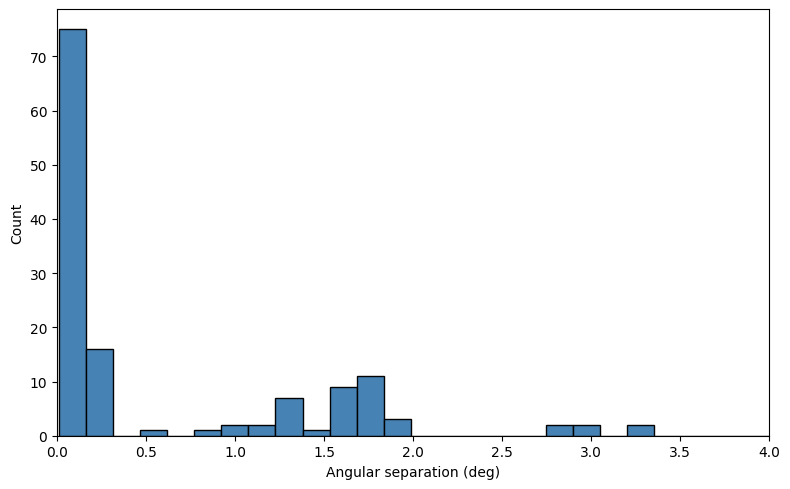

In [6]:
import matplotlib.pyplot as plt

sep_arcsec = df['sep_deg'].dropna()

plt.figure(figsize=(8, 5))
plt.hist(sep_arcsec, bins=400, color='steelblue', edgecolor='black')
plt.xlabel('Angular separation (deg)')
plt.ylabel('Count')
plt.xlim(0,4)
# plt.title('Histogram of sep_arcsec')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1303596/1776732564.py:18: RuntimeWarning: invalid value encountered in divide
  beam = (np.sin(u) / u) ** 2


400 MHz: FWHM ≈ 0.95 deg, analytic 0.886*lambda/D = 1.90 deg
600 MHz: FWHM ≈ 0.63 deg, analytic 0.886*lambda/D = 1.27 deg
800 MHz: FWHM ≈ 0.47 deg, analytic 0.886*lambda/D = 0.95 deg


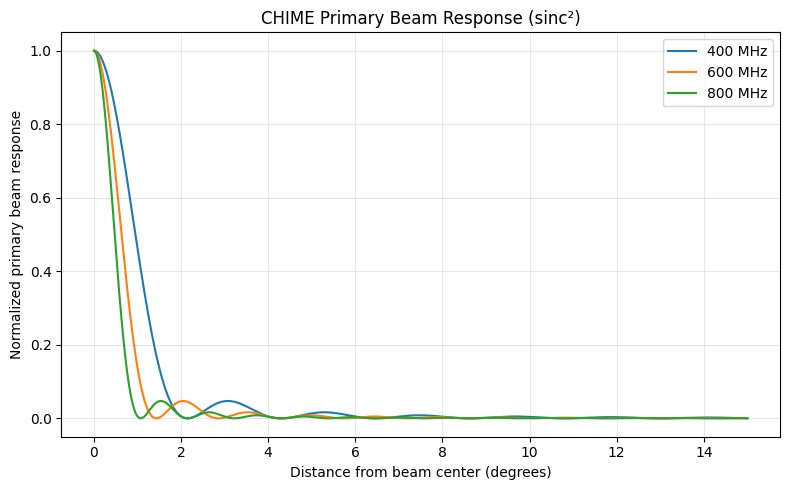

In [22]:
import numpy as np
import matplotlib.pyplot as plt

D = 20.0      # effective E-W aperture (m)
c = 3e8

freqs_MHz = [400, 600, 800]
theta_deg = np.linspace(0, 15, 2000)
theta_rad = np.deg2rad(theta_deg)

plt.figure(figsize=(8, 5))

for freq_MHz in freqs_MHz:
    wavelength = c / (freq_MHz * 1e6)

    # Correct sinc argument: u = pi * D * sin(theta) / lambda
    u = np.pi * D * np.sin(theta_rad) / wavelength
    beam = (np.sin(u) / u) ** 2
    beam[u == 0] = 1.0  # handle singularity at theta=0

    # Check FWHM numerically
    half_max_idx = np.where(beam >= 0.5)[0]
    fwhm = theta_deg[half_max_idx[-1]] - theta_deg[half_max_idx[0]]
    print(f"{freq_MHz} MHz: FWHM ≈ {fwhm:.2f} deg, "
          f"analytic 0.886*lambda/D = {np.degrees(0.886*wavelength/D):.2f} deg")

    plt.plot(theta_deg, beam, label=f'{freq_MHz} MHz')

plt.xlabel('Distance from beam center (degrees)')
plt.ylabel('Normalized primary beam response')
plt.title('CHIME Primary Beam Response (sinc²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chime_primary_beam.png', dpi=150)
plt.show()

/tmp/ipykernel_2514989/2437580909.py:23: RuntimeWarning: invalid value encountered in divide
  beam = (np.sin(u) / u) ** 2


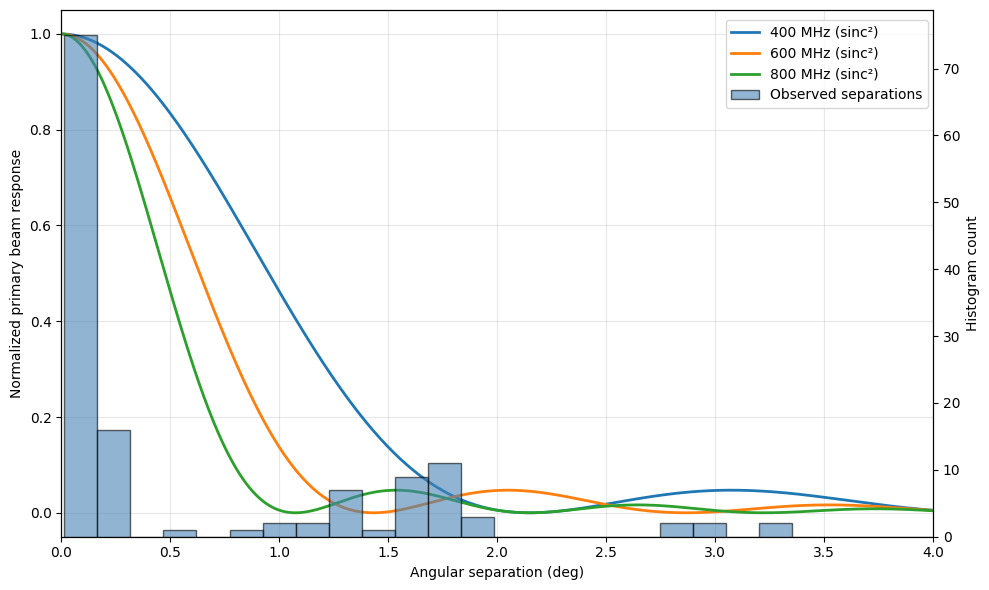

In [7]:

import matplotlib.pyplot as plt
import numpy as np

sep_arcsec = df['sep_deg'].dropna()

D = 20.0      # effective E-W aperture (m)
c = 3e8
freqs_MHz = [400, 600, 800]
theta_deg = np.linspace(0, 15, 2000)
theta_rad = np.deg2rad(theta_deg)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot sinc² beam patterns on left y-axis
color = 'tab:blue'
ax1.set_xlabel('Angular separation (deg)')
ax1.set_ylabel('Normalized primary beam response')
ax1.tick_params(axis='y')

for freq_MHz in freqs_MHz:
    wavelength = c / (freq_MHz * 1e6)
    u = np.pi * D * np.sin(theta_rad) / wavelength
    beam = (np.sin(u) / u) ** 2
    beam[u == 0] = 1.0
    
    ax1.plot(theta_deg, beam, linewidth=2, label=f'{freq_MHz} MHz (sinc²)', color=None)

ax1.set_xlim(0, 4)
ax1.grid(True, alpha=0.3)

# Plot histogram on right y-axis
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Histogram count')
ax2.tick_params(axis='y')
ax2.hist(sep_arcsec, bins=400, color='steelblue', edgecolor='black', alpha=0.6, label='Observed separations')

fig.legend(loc='upper right', bbox_to_anchor=(0.94, 0.97))
plt.tight_layout()
plt.show()

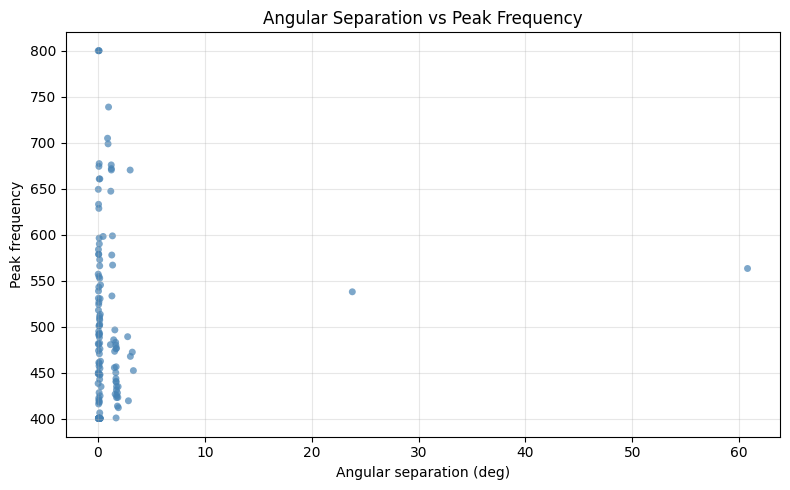

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Use the table that already has peak_freq and sep_deg
df = pd.read_csv("cross_matched_with_separation.csv")

# Clean up missing values
sep = df['sep_deg'].dropna()
peak_freq = df['peak_freq'].dropna()

plt.figure(figsize=(8, 5))
plt.scatter( sep, peak_freq, s=25, alpha=0.7, color='steelblue', edgecolors='none')
plt.ylabel('Peak frequency')
plt.xlabel('Angular separation (deg)')
plt.title('Angular Separation vs Peak Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.xlim(0, 10)
plt.show()

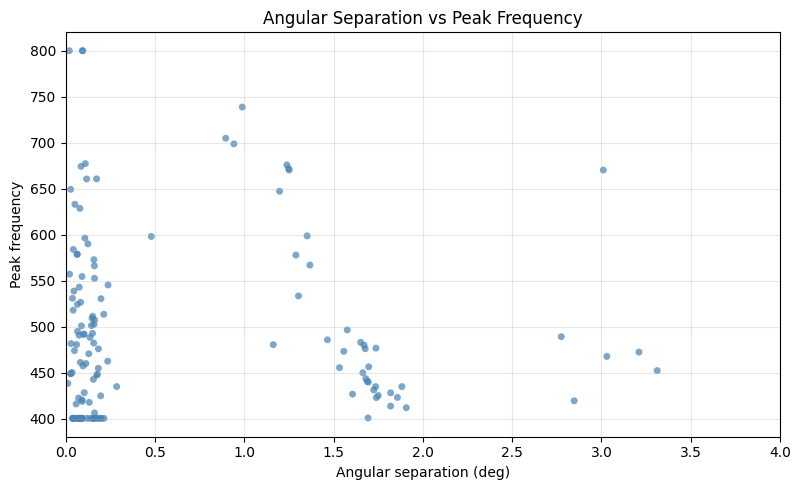

In [17]:
# Use the table that already has peak_freq and sep_deg
df = pd.read_csv("cross_matched_with_separation.csv")

# Clean up missing values
sep = df['sep_deg'].dropna()
peak_freq = df['peak_freq'].dropna()

plt.figure(figsize=(8, 5))
plt.scatter( sep, peak_freq, s=25, alpha=0.7, color='steelblue', edgecolors='none')
plt.ylabel('Peak frequency')
plt.xlabel('Angular separation (deg)')
plt.title('Angular Separation vs Peak Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.xlim(0, 4)
plt.show()